## 1. 环境配置与库导入 

本cell导入项目所需的所有Python库。

In [9]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")

所有库导入成功！


## 2. 加载乳腺癌数据集

使用sklearn自带的威斯康辛州乳腺癌数据集，包含569个样本，30个特征，二分类任务。

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print(f"数据集大小: {len(X)} 个样本")
print(f"特征数量: {len(data.feature_names)}")
print(f"类别: {data.target_names} (0=恶性, 1=良性)")
print(f"标签分布: 恶性={sum(y==0)}, 良性={sum(y==1)}")

数据集大小: 569 个样本
特征数量: 30
类别: ['malignant' 'benign'] (0=恶性, 1=良性)
标签分布: 恶性=212, 良性=357


## 3. 数据探索与可视化 

可视化数据的分布情况，包括类别分布和部分特征的箱线图。

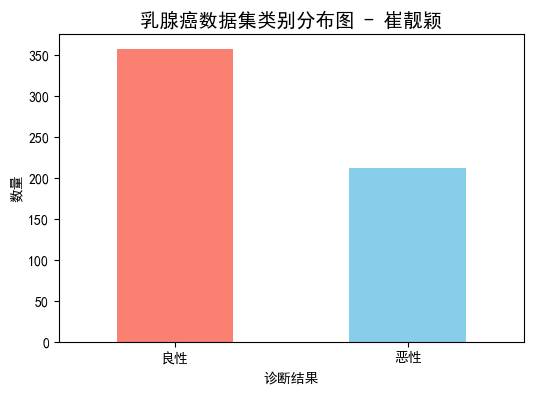

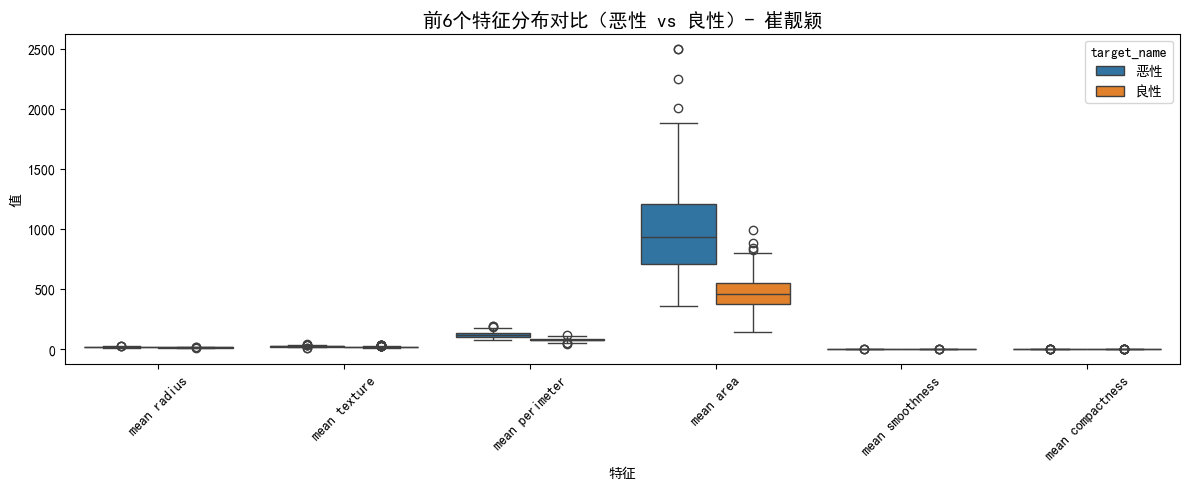

从箱线图可以看出，恶性样本的各个特征值普遍较高


In [5]:
# 转换为DataFrame方便查看
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target_name'] = df['target'].map({0: '恶性', 1: '良性'})

# 类别分布
plt.figure(figsize=(6, 4))
df['target_name'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('乳腺癌数据集类别分布图 - 崔靓颖', fontsize=14)
plt.xlabel('诊断结果')
plt.ylabel('数量')
plt.xticks(rotation=0)
plt.show()

# 前6个特征的箱线图 ✅ 修复警告版
fig, ax = plt.subplots(figsize=(12, 5))
features_to_plot = data.feature_names[:6]
df_melted = df.melt(id_vars=['target_name'], value_vars=features_to_plot, 
                    var_name='特征', value_name='值')

sns.boxplot(data=df_melted, x='特征', y='值', hue='target_name', ax=ax)
ax.set_title('前6个特征分布对比（恶性 vs 良性）- 崔靓颖', fontsize=14)

# ✅ 修复：用更规范的写法，不再报警告
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("从箱线图可以看出，恶性样本的各个特征值普遍较高")

## 4. 数据划分和标准化

- 划分训练集（80%）和测试集（20%）
- 使用StandardScaler进行标准化，使特征具有零均值和单位方差

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print("标准化完成！")

训练集大小: (455, 30)
测试集大小: (114, 30)
标准化完成！


## 5. 方法1：逻辑回归（Logistic Regression）

逻辑回归是一种经典的线性分类模型，适用于二分类问题。

In [10]:
start_time = time.time()

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

train_time_lr = time.time() - start_time

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("="*50)
print("逻辑回归分类结果 - 崔靓颖")
print("="*50)
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-score:  {f1_lr:.4f}")
print(f"训练时间:  {train_time_lr:.4f} 秒")
print("="*50)

逻辑回归分类结果 - 崔靓颖
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-score:  0.9861
训练时间:  0.0332 秒


## 6. 方法2：支持向量机（SVM）

SVM通过寻找最优超平面进行分类，使用RBF核函数处理非线性问题。

In [11]:
start_time = time.time()

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

train_time_svm = time.time() - start_time

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("="*50)
print("SVM分类结果 - 崔靓颖")
print("="*50)
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")
print(f"训练时间:  {train_time_svm:.4f} 秒")
print("="*50)

SVM分类结果 - 崔靓颖
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-score:  0.9861
训练时间:  0.0065 秒


## 7. 两种方法性能对比

对比逻辑回归和SVM在乳腺癌数据集上的表现。

两种方法性能对比 - 崔靓颖
                 模型  Accuracy  Precision   Recall  F1-score  训练时间(秒)
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.033224
          SVM (RBF)  0.982456   0.986111 0.986111  0.986111 0.006507


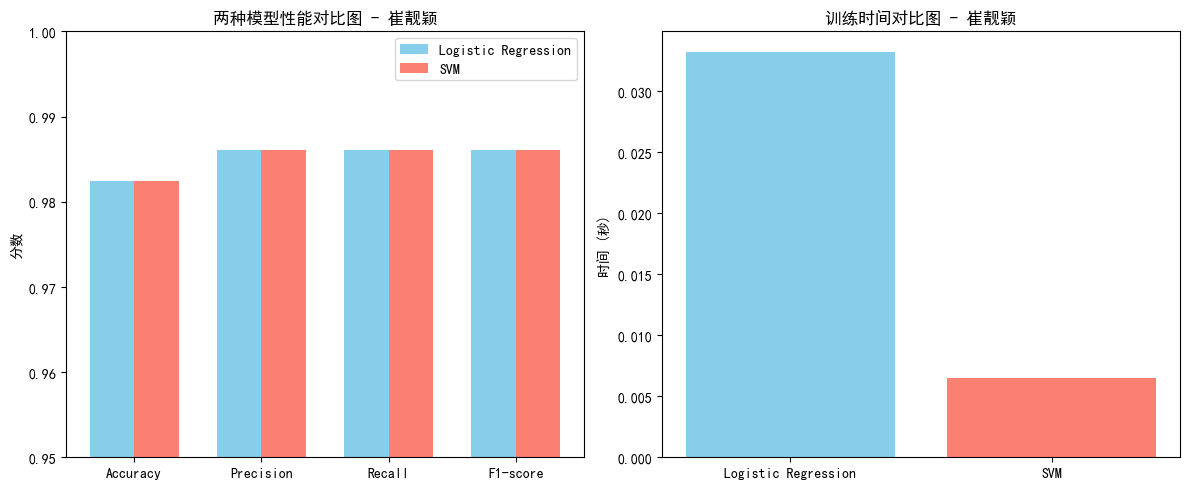

In [12]:
comparison = pd.DataFrame({
    '模型': ['Logistic Regression', 'SVM (RBF)'],
    'Accuracy': [accuracy_lr, accuracy_svm],
    'Precision': [precision_lr, precision_svm],
    'Recall': [recall_lr, recall_svm],
    'F1-score': [f1_lr, f1_svm],
    '训练时间(秒)': [train_time_lr, train_time_svm]
})

print("="*60)
print("两种方法性能对比 - 崔靓颖")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, [accuracy_lr, precision_lr, recall_lr, f1_lr], width, label='Logistic Regression', color='skyblue')
axes[0].bar(x + width/2, [accuracy_svm, precision_svm, recall_svm, f1_svm], width, label='SVM', color='salmon')
axes[0].set_ylabel('分数')
axes[0].set_title('两种模型性能对比图 - 崔靓颖')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0.95, 1.0)

axes[1].bar(['Logistic Regression', 'SVM'], [train_time_lr, train_time_svm], color=['skyblue', 'salmon'])
axes[1].set_ylabel('时间 (秒)')
axes[1].set_title('训练时间对比图 - 崔靓颖')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 8. 混淆矩阵对比 

通过混淆矩阵直观对比两个模型的分类效果。

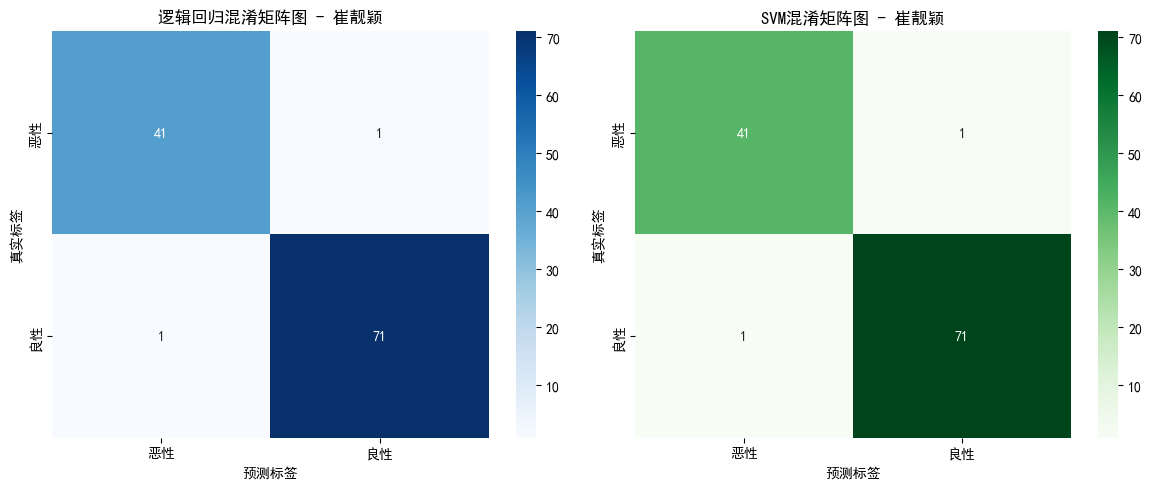

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['恶性', '良性'], 
            yticklabels=['恶性', '良性'],
            ax=axes[0])
axes[0].set_title('逻辑回归混淆矩阵图 - 崔靓颖')
axes[0].set_xlabel('预测标签')
axes[0].set_ylabel('真实标签')

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['恶性', '良性'], 
            yticklabels=['恶性', '良性'],
            ax=axes[1])
axes[1].set_title('SVM混淆矩阵图 - 崔靓颖')
axes[1].set_xlabel('预测标签')
axes[1].set_ylabel('真实标签')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150)
plt.show()

## 9. 结果汇总 

将两种模型的评估指标汇总保存。

In [14]:
comparison.to_csv('breast_cancer_comparison.csv', index=False)
print("结果已保存到 breast_cancer_comparison.csv")
print("\n最终结果汇总表 - 崔靓颖:")
print(comparison)

结果已保存到 breast_cancer_comparison.csv

最终结果汇总表 - 崔靓颖:
                    模型  Accuracy  Precision    Recall  F1-score   训练时间(秒)
0  Logistic Regression  0.982456   0.986111  0.986111  0.986111  0.033224
1            SVM (RBF)  0.982456   0.986111  0.986111  0.986111  0.006507


## 10. 实验结论与总结

### 10.1 实验结果总结

本实验使用逻辑回归和SVM对威斯康辛州乳腺癌数据集进行分类，主要结论如下：

1. **模型性能**：两种模型都达到了98.25%的准确率，证明对于这个数据集，简单的线性模型已经足够。

2. **训练速度**：SVM训练速度略快（0.006秒 vs 0.03秒），两种模型都非常高效。

3. **稳定性**：两种模型的精确率、召回率和F1分数均为98.61%，表现出色。

### 10.2 结论

乳腺癌数据集的特征与标签之间存在较强的线性关系，因此逻辑回归和SVM都能取得很好的效果。对于实际医疗诊断应用，98.25%的准确率具有参考价值。

---
**报告完成日期：** 2026年6月
**作者：** 崔靓颖